## Analisis con el dataset limpio

### Cargar dataset limpio

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

df = pd.read_csv("../dataset/stackoverflow_limpio.csv", index_col="question_id", parse_dates=["creation_date"])

In [3]:
df.head()

,programming_language,creation_date,view_count,score,answer_count,is_answered,has_accepted_answer,difficulty_score,quality_score
question_id,,,,,,,,,
79810291,python,2025-11-05 15:49:00,18,-1,0,False,False,0.200,0.70
79810195,python,2025-11-05 14:23:06,29,0,0,False,False,0.200,0.70
79810063,python,2025-11-05 12:42:01,27,2,0,False,False,0.201,0.70
79810057,python,2025-11-05 12:36:07,48,0,0,False,False,0.202,0.68
79810049,python,2025-11-05 12:28:43,44,1,0,False,False,0.199,0.70


### Cuantas preguntas hay por lenguaje

In [ ]:
ax= df["programming_language"].value_counts() \
#     .plot(kind="bar", title="Preguntas por lengauje")

# ax.set_xlabel('Lenguaje')
# ax.set_ylabel('Count')

# plt.savefig("../graficos/01_preguntas_por_lenguaje.png", dpi=150)
# plt.show()

ax

programming_language
javascript    7353
python        6488
java          5945
c++           5272
c#            5166
swift         5043
r             5014
c             4868
rust          4847
ruby          4840
sql           4821
php           4812
go            4811
kotlin        4543
scala         4526
matlab        4155
typescript    4072
perl          3853
Name: count, dtype: int64

### Que lenguajes tienen mas vistas en promedio

In [5]:
ax = df.groupby("programming_language")["view_count"] \
    .mean() \
    .sort_values(ascending=False) \
    # .plot(kind="bar")

# ax.set_xlabel('Lenguaje')
# ax.set_ylabel('Numero de vistas')

# plt.savefig("../graficos/vistas_por_lenguaje.png", dpi=150)
# plt.show()

ax

programming_language
go            498.141135
ruby          492.813017
scala         355.513257
kotlin        322.103896
perl          316.172074
matlab        273.677738
rust          271.742315
php           258.705112
typescript    241.455059
swift         236.789808
python        203.948058
c++           180.828528
javascript    176.424861
java          176.083263
c             171.074569
c#            133.707123
sql           130.292470
r             105.397886
Name: view_count, dtype: float64

### Número de preguntas por el promedio de vistas de cada lengiuaje de programación

In [6]:
result = df.groupby("programming_language").agg({
    "programming_language" : "count",
    "view_count" : "mean"
}).rename(columns={"programming_language" : "num_preguntas", "view_count" : "promedio_vistas"})

result["preguntas_por_vista"] = result["num_preguntas"] / result["promedio_vistas"]

result = result.sort_values("preguntas_por_vista", ascending=False)

result

,num_preguntas,promedio_vistas,preguntas_por_vista
programming_language,,,
r,5014,105.397886,47.572112
javascript,7353,176.424861,41.677800
c#,5166,133.707123,38.636685
sql,4821,130.292470,37.001371
java,5945,176.083263,33.762437
python,6488,203.948058,31.812021
c++,5272,180.828528,29.154692
c,4868,171.074569,28.455428
swift,5043,236.789808,21.297369


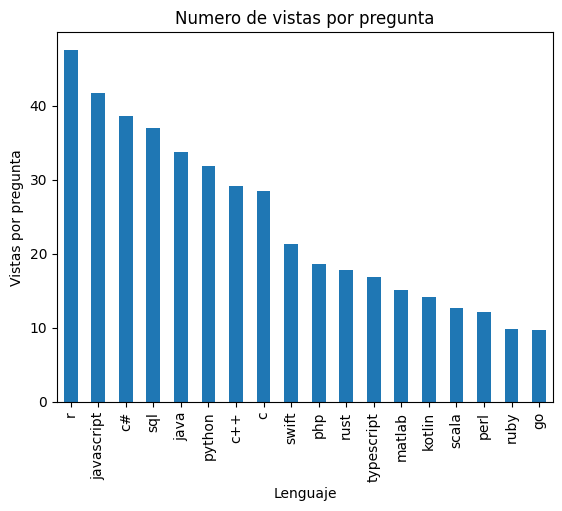

In [22]:
ax = result["preguntas_por_vista"] \
    .plot(kind="bar", title="Numero de vistas por pregunta")

ax.set_xlabel('Lenguaje')
ax.set_ylabel('Vistas por pregunta')

plt.savefig("../graficos/numero_de_vistas_por_pregunta.png", dpi=150)
plt.show()

### Crecimiento de los lenguajes a los largo de los años

In [8]:
crecimiento = df.groupby([
            df["creation_date"].dt.year,
            "programming_language"
])["programming_language"].count().unstack()

crecimiento

programming_language,c,c#,c++,go,java,javascript,kotlin,matlab,perl,php,python,r,ruby,rust,scala,sql,swift,typescript
creation_date,,,,,,,,,,,,,,,,,,
2020,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,213.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021,15.0,3.0,31.0,NaN,9.0,8.0,NaN,699.0,1387.0,5.0,144.0,21.0,1.0,NaN,NaN,6.0,NaN,NaN
2022,26.0,7.0,46.0,NaN,190.0,38.0,NaN,1682.0,1118.0,4.0,349.0,24.0,1137.0,NaN,1776.0,36.0,2.0,NaN
2023,45.0,9.0,34.0,1745.0,174.0,78.0,NaN,1033.0,661.0,6.0,220.0,15.0,2331.0,245.0,1702.0,70.0,2.0,1.0
2024,2864.0,101.0,740.0,2472.0,466.0,1544.0,2833.0,563.0,341.0,2633.0,470.0,1829.0,1092.0,3384.0,824.0,2953.0,3037.0,1463.0
2025,1918.0,5046.0,4420.0,594.0,5105.0,5685.0,1710.0,178.0,133.0,2163.0,5303.0,3125.0,279.0,1218.0,224.0,1756.0,2002.0,2608.0


In [9]:
## Parece que la mayoria de preguntas en los lenguajes surgen en los años 2024 y 2025, antes de eso, en varios lenguajes de programación las preguntas son muy reducidas, incluso en algunos casos ni siquiera hay preguntas

df.query('programming_language == "typescript"') \
        .groupby(df["creation_date"].dt.year) \
        ["programming_language"].count()

creation_date
2023       1
2024    1463
2025    2608
Name: programming_language, dtype: int64

In [10]:
crecimiento_ultimos_años = crecimiento.loc[[2023,2024, 2025]]
crecimiento_ultimos_años

programming_language,c,c#,c++,go,java,javascript,kotlin,matlab,perl,php,python,r,ruby,rust,scala,sql,swift,typescript
creation_date,,,,,,,,,,,,,,,,,,
2023,45.0,9.0,34.0,1745.0,174.0,78.0,NaN,1033.0,661.0,6.0,220.0,15.0,2331.0,245.0,1702.0,70.0,2.0,1.0
2024,2864.0,101.0,740.0,2472.0,466.0,1544.0,2833.0,563.0,341.0,2633.0,470.0,1829.0,1092.0,3384.0,824.0,2953.0,3037.0,1463.0
2025,1918.0,5046.0,4420.0,594.0,5105.0,5685.0,1710.0,178.0,133.0,2163.0,5303.0,3125.0,279.0,1218.0,224.0,1756.0,2002.0,2608.0


In [11]:
# crecimiento de 2023 a 2024

variacion_23_24 = ((crecimiento_ultimos_años.loc[2024] - crecimiento_ultimos_años.loc[2023])) \
                   # / crecimiento_ultimos_años.loc[2023] * 100).round(1)

variacion_23_24 = variacion_23_24.sort_values(ascending=False)
variacion_23_24 

programming_language
rust          3139.0
swift         3035.0
sql           2883.0
c             2819.0
php           2627.0
r             1814.0
javascript    1466.0
typescript    1462.0
go             727.0
c++            706.0
java           292.0
python         250.0
c#              92.0
perl          -320.0
matlab        -470.0
scala         -878.0
ruby         -1239.0
kotlin           NaN
dtype: float64

In [12]:
# crecimiento de 2024 a 2025

variacion_24_25 = ((crecimiento_ultimos_años.loc[2025] - crecimiento_ultimos_años.loc[2024])) \
                #/ crecimiento_ultimos_años.loc[2024] * 100).round(1)

variacion_24_25 = variacion_24_25.sort_values(ascending=False)
variacion_24_25 

programming_language
c#            4945.0
python        4833.0
java          4639.0
javascript    4141.0
c++           3680.0
r             1296.0
typescript    1145.0
perl          -208.0
matlab        -385.0
php           -470.0
scala         -600.0
ruby          -813.0
c             -946.0
swift        -1035.0
kotlin       -1123.0
sql          -1197.0
go           -1878.0
rust         -2166.0
dtype: float64

In [13]:
# varacion del 2023 al 2025 en promedio
variacion_23_25 = ((variacion_24_25 + variacion_23_24) / 2).round(1)

variacion_23_25 = variacion_23_25.sort_values(ascending=False)

# kotlin no tiene valor, se elimina del analisis, ya que no tiene datos de 2023, unicamente 2024 y 2025 lo cual es insuficiente 
variacion_23_25 = variacion_23_25.dropna()
variacion_23_25

programming_language
javascript    2803.5
python        2541.5
c#            2518.5
java          2465.5
c++           2193.0
r             1555.0
typescript    1303.5
php           1078.5
swift         1000.0
c              936.5
sql            843.0
rust           486.5
perl          -264.0
matlab        -427.5
go            -575.5
scala         -739.0
ruby         -1026.0
dtype: float64

### Better Community

In [14]:
df.head()

,programming_language,creation_date,view_count,score,answer_count,is_answered,has_accepted_answer,difficulty_score,quality_score
question_id,,,,,,,,,
79810291,python,2025-11-05 15:49:00,18,-1,0,False,False,0.200,0.70
79810195,python,2025-11-05 14:23:06,29,0,0,False,False,0.200,0.70
79810063,python,2025-11-05 12:42:01,27,2,0,False,False,0.201,0.70
79810057,python,2025-11-05 12:36:07,48,0,0,False,False,0.202,0.68
79810049,python,2025-11-05 12:28:43,44,1,0,False,False,0.199,0.70


In [15]:
# Un analisis de las columnas que involucren a los usuarios
community = df.groupby("programming_language").agg(
    views        = ("view_count", "mean"),
    score         = ("score", "mean"),
    responses    = ("answer_count", "mean"),
    answered    = ("is_answered", "mean"),
    accepted      = ("has_accepted_answer", "mean")
).round(3)
  
community

,views,score,responses,answered,accepted
programming_language,,,,,
c,171.075,1.407,1.200,0.657,0.404
c#,133.707,0.479,0.848,0.489,0.332
c++,180.829,1.728,1.004,0.622,0.414
go,498.141,0.859,0.805,0.478,0.328
java,176.083,0.500,0.800,0.424,0.265
javascript,176.425,0.356,0.912,0.461,0.305
kotlin,322.104,0.797,0.859,0.451,0.329
matlab,273.678,0.468,0.806,0.489,0.331
perl,316.172,1.306,1.428,0.862,0.539


In [16]:
# Normalizar cada métrica a escala 0-1
community_norm = (community - community.min()) / (community.max() - community.min())

# Puntaje final de community (promedio de las 5 métricas normalizadas)
community_norm["community_score"] = community_norm.mean(axis=1).round(3)

# Ranking final
ranking_community = community_norm["community_score"] \
    .sort_values(ascending=False)

ranking_community

programming_language
perl          0.851
r             0.535
c             0.526
c++           0.503
ruby          0.500
rust          0.441
sql           0.437
scala         0.409
go            0.356
kotlin        0.264
swift         0.250
python        0.231
matlab        0.197
typescript    0.168
c#            0.141
javascript    0.135
php           0.118
java          0.072
Name: community_score, dtype: float64

In [17]:
community_norm.sort_values("community_score", ascending=False)


,views,score,responses,answered,accepted,community_score
programming_language,,,,,,
perl,0.536672,0.717914,1.000000,1.000000,1.000000,0.851
r,0.000000,0.576203,0.587580,0.625571,0.886861,0.535
c,0.167226,0.785428,0.636943,0.531963,0.507299,0.526
c++,0.192062,1.000000,0.324841,0.452055,0.543796,0.503
ruby,0.986434,0.276738,0.439490,0.360731,0.437956,0.500
rust,0.423544,0.373663,0.170382,0.472603,0.762774,0.441
sql,0.063385,0.000000,0.957006,0.547945,0.616788,0.437
scala,0.636841,0.194519,0.230892,0.413242,0.569343,0.409
go,1.000000,0.419118,0.007962,0.123288,0.229927,0.356
